# Perform ARIMA analysis on the data

In [84]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.time import Time
from statsmodels.tsa.arima.model import ARIMA
from matplotlib.ticker import MultipleLocator
from scipy.stats import boxcox

- Let us work with PD here for simplicity. 

In [86]:
data = pd.read_csv(r"./Data/sind_subset1_3.txt", sep='\s',skip_blank_lines=True, header = None)
data.columns = ["JD", "sind"]
time_obj = Time(data["JD"].to_numpy(), format='jd', scale='tdb')
data["year"] = time_obj.jyear
data['datetime'] = time_obj.to_datetime(timezone=None)
data = data.set_index('datetime')
data


C:\Users\Joey\AppData\Local\Temp\ipykernel_46784\2443593090.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(r"./Data/sind_subset1_3.txt", sep='\s',skip_blank_lines=True, header = None)


,JD,sind,year
datetime,,,
1966-09-02 08:34:04.799986,2439370.857,0.173873,1966.669013
1966-09-03 08:13:55.199989,2439371.843,0.175041,1966.671713
1966-09-04 07:55:12.000006,2439372.830,0.174457,1966.674415
1966-09-24 08:16:48.000018,2439392.845,0.175236,1966.729213
1966-09-25 07:56:38.399980,2439393.831,0.175918,1966.731912
...,...,...,...
1991-08-26 16:59:31.200009,2448495.208,0.181948,1991.650125
1991-08-28 16:59:31.200009,2448497.208,0.177421,1991.655600
1991-08-29 16:59:31.200009,2448498.208,0.179252,1991.658338


In [87]:
dataset_length = len(data)
train_split = 0.7
valid_split = 0.15
# test_split = 1 - train_split - valid_split

train_idx = round(train_split*dataset_length)
valid_idx = round((valid_split + train_split) * dataset_length)

train_df = data.iloc[:train_idx]
valid_df = data.iloc[train_idx:valid_idx]
test_df  = data.iloc[valid_idx:]

print(train_df.shape)
print(valid_df.shape)
print(test_df.shape)

(1184, 3)
(253, 3)
(254, 3)


- Now we want to check for stationarity to make sure the ARIMA model is applicable.
- Let us examine the training dataset to prevent data leakage.

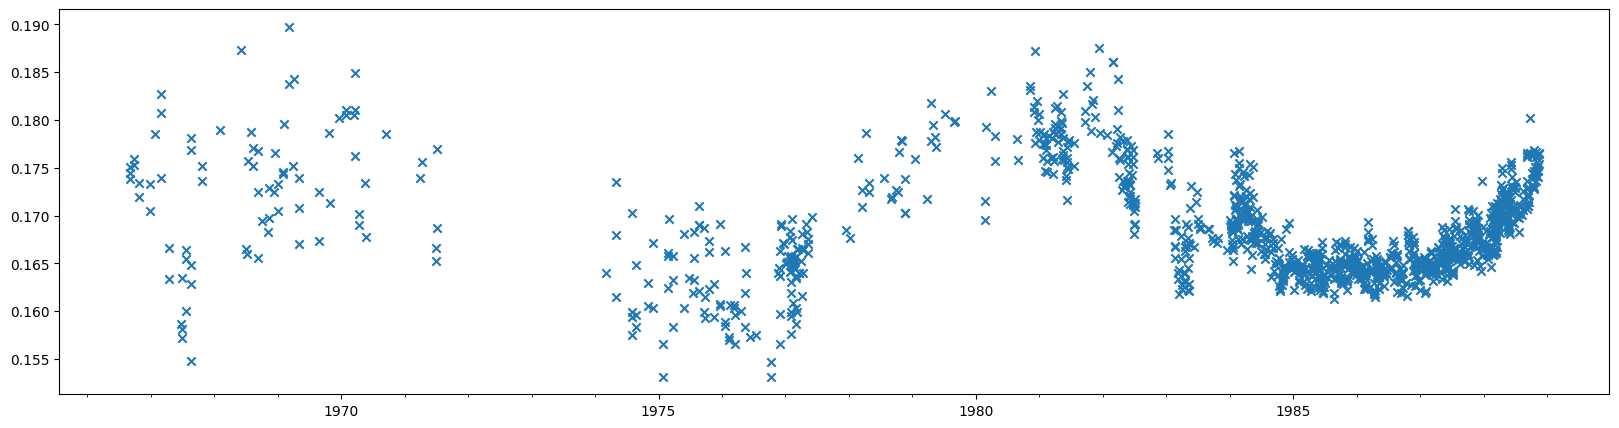

In [88]:
fig, ax = plt.subplots(figsize=(20,5))
plt.scatter(train_df["year"], train_df['sind'], marker='x')
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))

- Looks vaguely sinusoidal
- Peaks at 1970ish and 1981ish
- Troughs at 1976ish and 1986ish
- This corresponds to the roughly 10 to 11 year solar cycle

----

- The variance of the data does not look constant
- We can check the mean of the data by checking the average values at the minima we have observed

In [89]:
trough1976 = data[data['year'].between(1975,1977)]
trough1986 = data[data['year'].between(1985,1987)]
mean1976 = trough1976['sind'].mean()
mean1986 = trough1986['sind'].mean()
mean_delta = abs(mean1976-mean1986)
data_range = data['sind'].max() - data['sind'].min()
print(f"The change in means is {mean_delta} out of overall range delta {data_range}")
print(f'Percentage {100*mean_delta/data_range:.2f}%')


The change in means is 0.0019412766020864003 out of overall range delta 0.03818200000000002
Percentage 5.08%


- This seems similar enough considering the uncertainty in the estimating the trough.
- Now how to fix the variance.
- No idea how the variance varies so use a Box-Cox transform to normalise.

C:\Users\Joey\AppData\Local\Temp\ipykernel_46784\2668574017.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['sind_norm'], lambda_ = boxcox(train_df['sind'])


np.float64(-6.911692206105492)

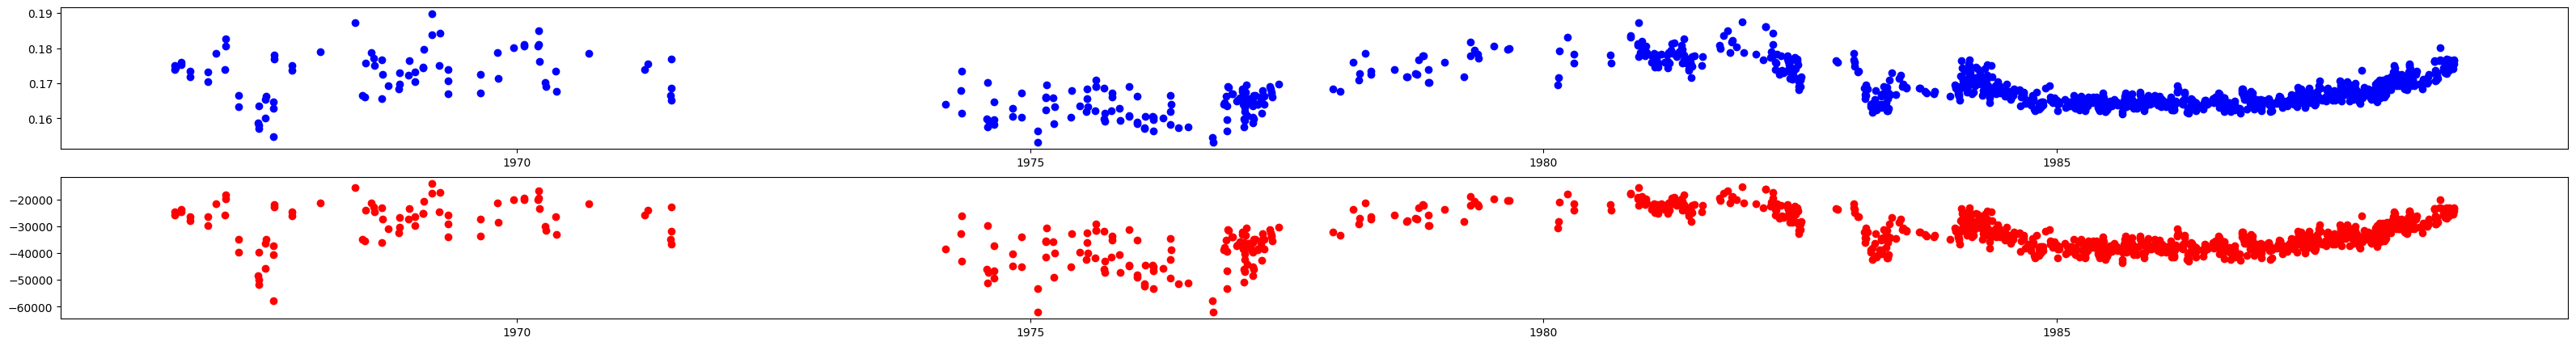

In [105]:
train_df['sind_norm'], lambda_ = boxcox(train_df['sind']) 
fig, ax = s=plt.subplots(2,1 ,figsize=(40,5))
ax[0].scatter(train_df['year'], train_df['sind'], color = 'blue')
ax[1].scatter(train_df['year'], train_df['sind_norm'], color = 'red')
lambda_

- The next problem is that the data is not at fixed timesteps. 
- That four year gap is really problematic. Let's try interpolating it.
- This is still problematic. If we downsample to years we have very few datapoints but if we downsample to months we have too many interpolated ones. 
- Some approaches to try approaches:
    - Downsample to years; interpolate gap. 
    - Downsample to 6 months; reduced gap interpolation.
    - Downsample to months; massive interpolation.
    - Start analysis after gap; interp to month.
- The downsampling restricts the resolution of the solar cycle predictions.

In [141]:
# We will use four different versions of train_df to perform 
train_df_year = train_df.resample('YE').median().interpolate('time', limit =5) # resample years into groups, asfreq takes one per group 

train_df_6me = train_df.resample('6ME').median().interpolate('time', limit = 6)

train_df_me = train_df.resample('ME').median().interpolate('time', limit = 6)

train_df_gapme = train_df[train_df['year'] > 1973].resample('ME').median().interpolate('time', limit = 6) # use all data after 1973

na = [train_df_year.isna().sum(),
      train_df_6me.isna().sum(),
      train_df_me.isna().sum(),
      train_df_gapme.isna().sum(),
      ]

pd.set_option('display.max_rows', None)
print(train_df_year)
pd.reset_option('display.max_rows')

                      JD      sind         year     sind_norm
datetime                                                     
1966-12-31  2.439394e+06  0.173873  1966.731912 -25804.456712
1967-12-31  2.439682e+06  0.165887  1967.520464 -35721.777624
1968-12-31  2.440107e+06  0.172899  1968.684014 -26826.068759
1969-12-31  2.440314e+06  0.174360  1969.250815 -25310.396634
1970-12-31  2.440667e+06  0.178547  1970.217213 -21481.702719
1971-12-31  2.441135e+06  0.171341  1971.499914 -28742.832655
1972-12-31  2.441512e+06  0.168056  1972.531660 -33495.271003
1973-12-31  2.441888e+06  0.164780  1973.560587 -38234.724548
1974-12-31  2.442264e+06  0.161504  1974.589514 -42974.178092
1975-12-31  2.442632e+06  0.163257  1975.597114 -39884.283934
1976-12-31  2.442915e+06  0.160336  1976.371915 -45185.069175
1977-12-31  2.443196e+06  0.165090  1977.142253 -36923.134622
1978-12-31  2.443755e+06  0.172696  1978.672712 -27044.779034
1979-12-31  2.444001e+06  0.178828  1979.344854 -21256.331106
1980-12-

- The train_df_me has NaN values so let's skip that dataset.

In [145]:
from math import floor
# Print maxlags
def max_lags(df):
    n = len(df['sind_norm'])
    return floor(n/2)

print(f"{len(train_df_year)} datapoints in train_df_year, max lags = {max_lags(train_df_year)}")
print(f"{len(train_df_6me)} datapoints in train_df_6me, max lags = {max_lags(train_df_6me)}")
print(f"{len(train_df_gapme)} datapoints in train_df_gapme, max lags = {max_lags(train_df_gapme)}")


23 datapoints in train_df_year, max lags = 11
46 datapoints in train_df_6me, max lags = 23
177 datapoints in train_df_gapme, max lags = 88


- Now let's plot the ACF and PACF.
- Note to self: 
    - ACF is the correlation between a series and a lagged version of itself.
    - PACF is the correlation between a series and a lagged version with indirect effects removed.
    - The shaded bands indicate the regions in which the values would fall if they were white noise.

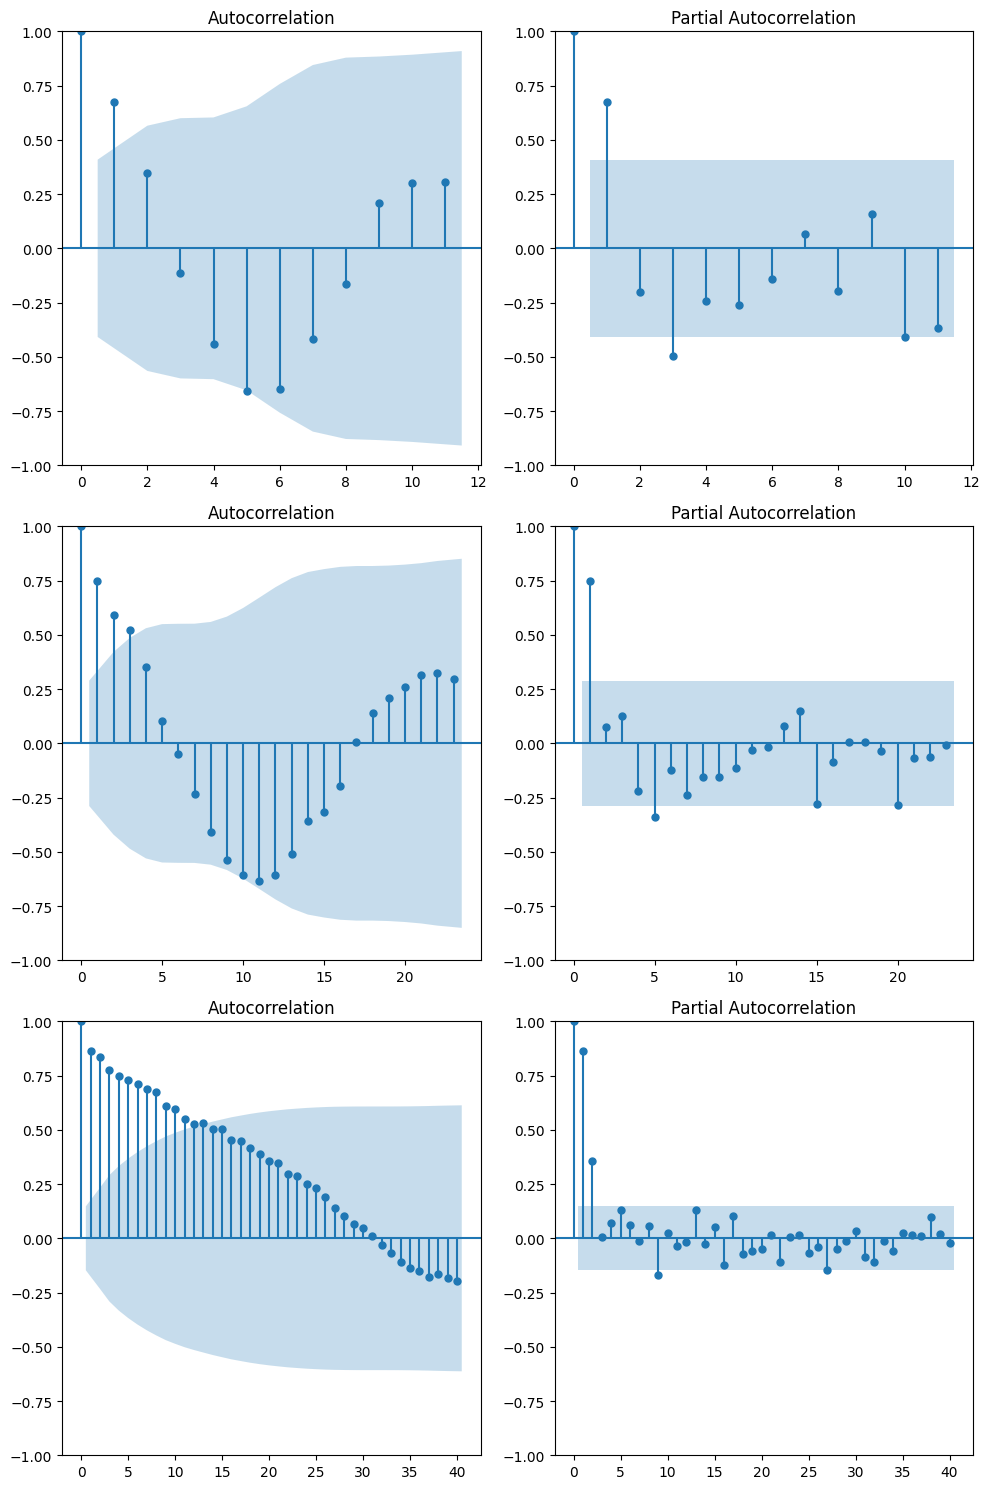

In [146]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(3,2, figsize=(10,15))

plot_acf(train_df_year['sind_norm'], lags=11, ax=ax[0,0]) # Using the maxlags
plot_pacf(train_df_year['sind_norm'], lags=11, ax=ax[0,1])

plot_acf(train_df_6me['sind_norm'], lags=23, ax=ax[1,0])
plot_pacf(train_df_6me['sind_norm'], lags=23, ax=ax[1,1])

plot_acf(train_df_gapme['sind_norm'], lags=40, ax=ax[2,0])
plot_pacf(train_df_gapme['sind_norm'], lags=40, ax=ax[2,1])

plt.tight_layout()
plt.show()

- The slow ACF decay implies non-stationarity: yesterday's value is a big contributor to today.
- The PACF is more or less a random walk because the lag 1 is the only non-negligible term.
    - $y_t = y_{t-1}+\epsilon_t$
- We can try remedy this with some differencing.